<a href="https://colab.research.google.com/github/edginasyafa273/edginasyafa273-H1D024046-PraktikumKB-Pertemuan7/blob/main/pertemuan7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 1000)           │         5,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 300)            │       150,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 3)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 656,703 (2.51 MB)

 Trainable params: 656,703 (2.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.3833 - loss: 1.0506 - val_accuracy: 0.7000 - val_loss: 0.7989
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7833 - loss: 0.7410 - val_accuracy: 0.7667 - val_loss: 0.5328
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9083 - loss: 0.4757 - val_accuracy: 0.8333 - val_loss: 0.3705
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8583 - loss: 0.3587 - val_accuracy: 0.8000 - val_loss: 0.4219
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8667 - loss: 0.3058 - val_accuracy: 0.8000 - val_loss: 0.2876
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9250 - loss: 0.2433 - val_accuracy: 0.8667 - val_loss: 0.2569
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9417 - loss: 0.1878 - val_accuracy: 0.9667 - val_loss: 0.1784
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9750 - loss: 0.1416 - val_accuracy: 0.8667 - val_loss: 0.1889


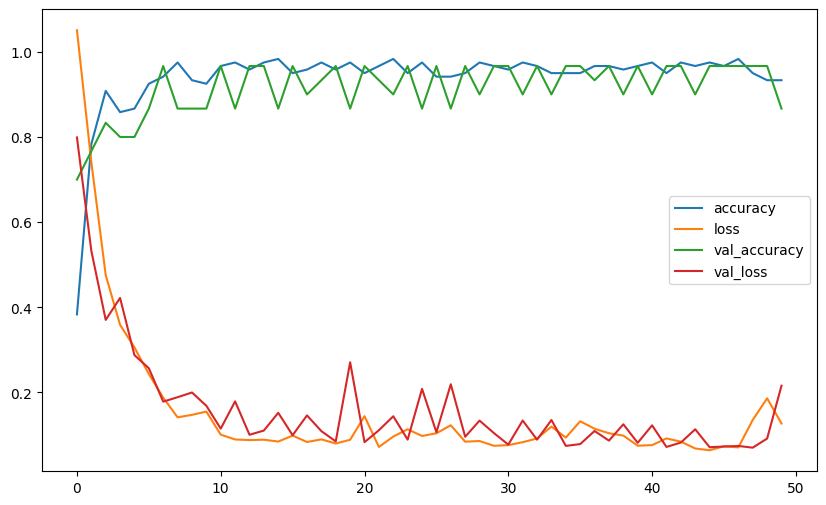

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Prediksi: [1 0 2 1 1 0 1 1 1 1 1 0 0 0 0 1 2 1 1 2 0 1 0 2 1 2 2 2 0 0]
Label Asli: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


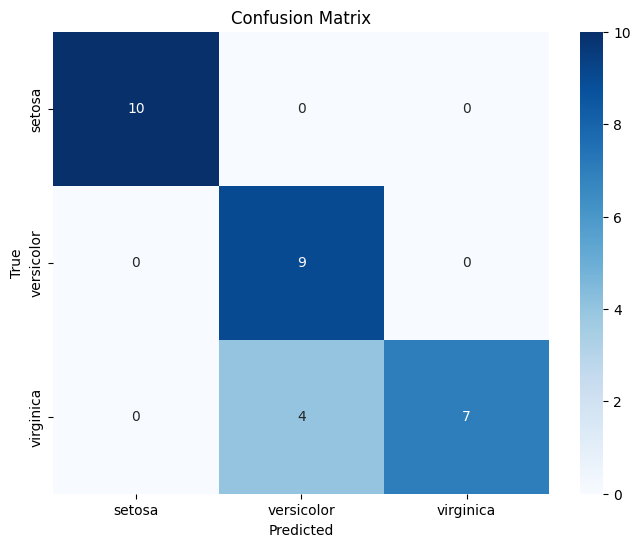

Masukkan sepal length: 5.1
Masukkan sepal width: 3.5
Masukkan petal length: 1.4
Masukkan petal width: 0.2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
Prediksi kelas: 0


In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Muat dataset iris dari sklearn
iris = load_iris()
X = iris.data
y = iris.target

# Mengonversi label dari string menjadi numerik
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)  # Mengubah label jadi 0, 1, 2

# Memisahkan dataset menjadi data latih dan data validasi dengan rasio 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Sequential([
    Input(shape=X_train.shape[1:]),
    Dense(1000, activation='relu'),
    Dense(500, activation='relu'),
    Dense(300, activation='relu'),
    Dense(3, activation='softmax')
])

model.summary()

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test)
)

loss, accuracy = model.evaluate(X_test, y_test)
print(f"Loss: {loss}, Accuracy: {accuracy}")

pd.DataFrame(history.history).plot(figsize=(10,6))
plt.show()

predictions = model.predict(X_test)

# Mengambil indeks dari nilai probabilitas tertinggi untuk setiap prediksi
predicted_classes = predictions.argmax(axis=1)

print("Prediksi:", predicted_classes)
print("Label Asli:", y_test)

# Buat confusion matrix
cm = confusion_matrix(y_test, predicted_classes)

# Visualisasikan confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Fungsi untuk memprediksi data input baru
def predict_new_data():
    sepal_length = float(input("Masukkan sepal length: "))
    sepal_width = float(input("Masukkan sepal width: "))
    petal_length = float(input("Masukkan petal length: "))
    petal_width = float(input("Masukkan petal width: "))

    # Membuat data array baru
    new_data = np.array([[sepal_length, sepal_width, petal_length, petal_width]])

    # Melakukan prediksi
    prediction = model.predict(new_data)
    predicted_class = prediction.argmax(axis=1)

    # Mengonversi hasil prediksi numerik menjadi label asli
    predicted_label = label_encoder.inverse_transform(predicted_class)
    print(f"Prediksi kelas: {predicted_label[0]}")

predict_new_data()